# 📚 Student Score Prediction
### Linear Regression Model

Predicting student exam scores based on:
- **Study Hours** per day
- **Attendance %**
- **Sleep Hours** per day

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [ ]:
df = pd.read_csv('student_dataset.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (1500, 4)

First 5 rows:


,Study_Hours,Attendance_Pct,Sleep_Hours,Score
0,4.4,71.1,7.4,55.5
1,9.6,68.8,8.0,88.2
2,7.6,41.5,5.3,52.9
3,6.4,60.5,7.1,60.7
4,2.4,62.8,6.9,43.1


In [ ]:
print('Basic Info:')
df.info()
print('\nStatistical Summary:')
df.describe().round(2)

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study_Hours     1500 non-null   float64
 1   Attendance_Pct  1500 non-null   float64
 2   Sleep_Hours     1500 non-null   float64
 3   Score           1500 non-null   float64
dtypes: float64(4)
memory usage: 47.0 KB

Statistical Summary:


,Study_Hours,Attendance_Pct,Sleep_Hours,Score
count,1500.00,1500.00,1500.00,1500.00
mean,5.50,70.03,6.45,58.04
std,2.65,17.36,1.43,14.69
min,1.00,40.00,4.00,20.00
25%,3.10,55.48,5.20,46.30
50%,5.60,70.30,6.40,58.00
75%,7.80,85.30,7.62,69.60
max,10.00,99.90,9.00,94.90


In [ ]:
print('Missing Values:', df.isnull().sum().sum())

Missing Values: 0


## 3. Exploratory Data Analysis (EDA)

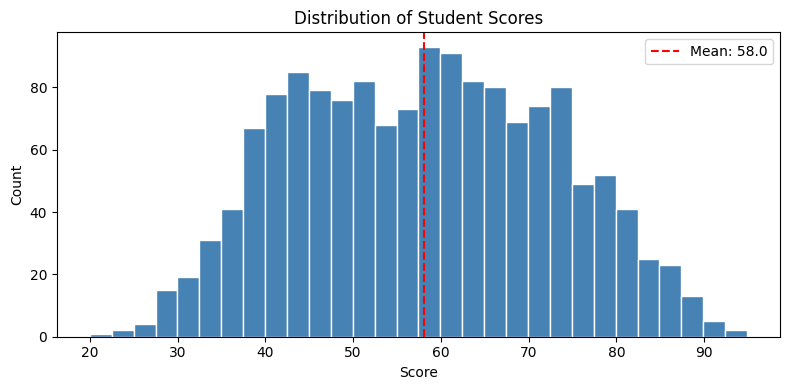

In [ ]:
# Distribution of Score
plt.figure(figsize=(8, 4))
plt.hist(df['Score'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['Score'].mean(), color='red', linestyle='--', label=f"Mean: {df['Score'].mean():.1f}")
plt.title('Distribution of Student Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

A healthy, near-normal distribution. The test was well-calibrated — not too easy, not too hard. Most students performed around average, with few extreme outliers on either end.

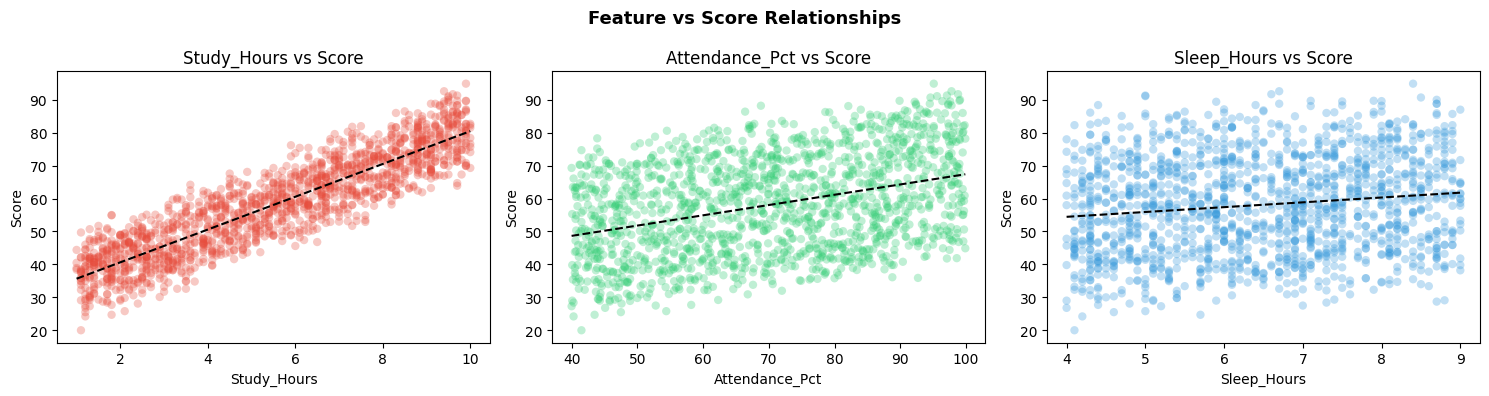

In [ ]:
# Scatter plots: each feature vs Score
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['Study_Hours', 'Attendance_Pct', 'Sleep_Hours']
colors   = ['#e74c3c', '#2ecc71', '#3498db']

for ax, feat, color in zip(axes, features, colors):
    ax.scatter(df[feat], df['Score'], alpha=0.3, color=color, edgecolors='none')
    # trend line
    z = np.polyfit(df[feat], df['Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5)
    ax.set_xlabel(feat)
    ax.set_ylabel('Score')
    ax.set_title(f'{feat} vs Score')

plt.suptitle('Feature vs Score Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Feature vs Score Relationships**

The scatter plots reveal how three factors relate to student performance. Study hours shows the strongest and most consistent positive correlation with scores — students who study more score significantly higher, with low scatter around the trend line, making it the most reliable predictor. Attendance percentage also has a positive relationship, though with considerably more spread, suggesting it supports performance but doesn't guarantee it. Sleep hours shows the weakest correlation, with a nearly flat trend line and wide scatter, indicating it has minimal standalone impact on scores. Overall, study hours is the dominant factor, attendance is a secondary contributor, and sleep hours alone is not a meaningful predictor of student performance.

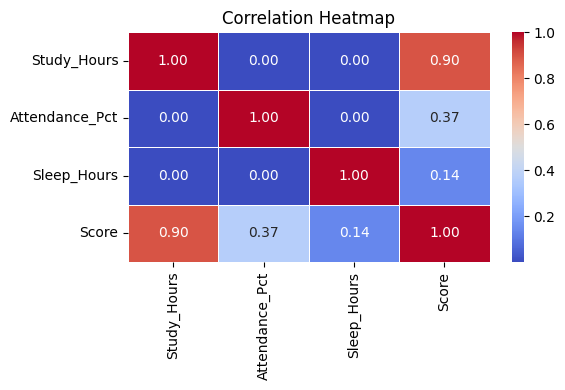

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Correlation Heatmap**

The heatmap confirms what the scatter plots suggested, but with exact numbers. Study hours has a very strong correlation with score (0.90), meaning it almost directly determines student performance. Attendance percentage has a moderate correlation (0.37), contributing to scores but with significant other factors at play. Sleep hours is weakly correlated (0.14), barely influencing scores in any meaningful way. The three features show zero correlation with each other (all 0.00), meaning they are completely independent variables — which is ideal for a predictive model as there is no multicollinearity to worry about. Overall, study hours is overwhelmingly the most influential feature, and the feature set is clean and independent.

## 4. Prepare Data for Modeling

In [ ]:
X = df[['Study_Hours', 'Attendance_Pct', 'Sleep_Hours']]
y = df['Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 1200
Testing samples  : 300


## 5. Train Linear Regression Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained!')
print(f'\nIntercept: {model.intercept_:.2f}')
print('\nCoefficients:')
for feat, coef in zip(X.columns, model.coef_):
    print(f'  {feat:<20}: {coef:.4f}')

Model trained!

Intercept: -0.25

Coefficients:
  Study_Hours         : 4.9813
  Attendance_Pct      : 0.3117
  Sleep_Hours         : 1.4127


## 6. Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=== Model Performance ===')
print(f'MAE  (Mean Absolute Error) : {mae:.2f}')
print(f'MSE  (Mean Squared Error)  : {mse:.2f}')
print(f'RMSE (Root MSE)            : {rmse:.2f}')
print(f'R²   (R-squared)           : {r2:.4f}')

=== Model Performance ===
MAE  (Mean Absolute Error) : 2.33
MSE  (Mean Squared Error)  : 8.98
RMSE (Root MSE)            : 3.00
R²   (R-squared)           : 0.9575


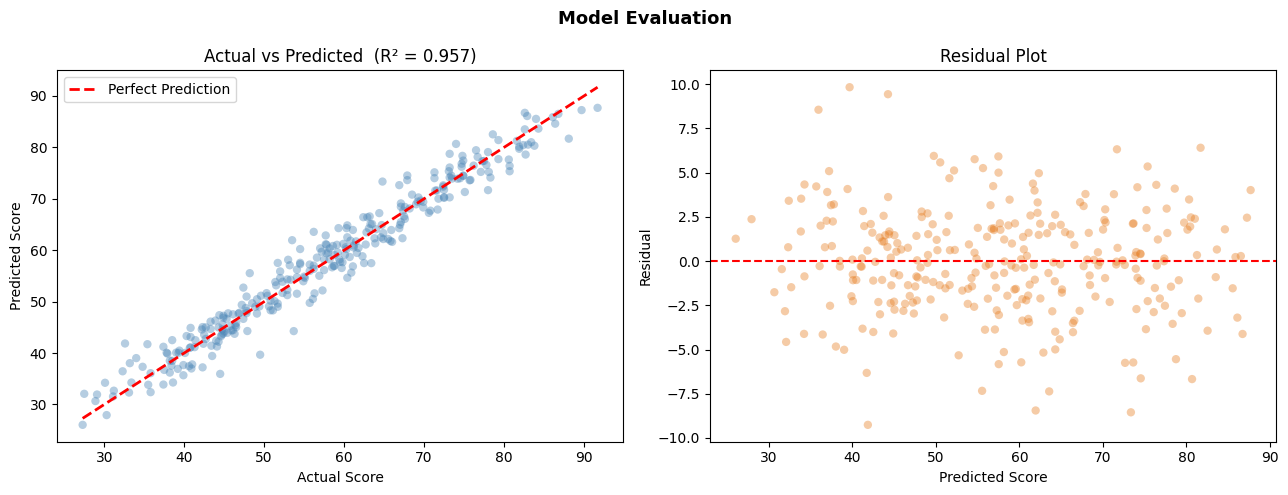

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='#e67e22', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Model Evaluation**

The model performs exceptionally well with an R² of 0.957, meaning it explains 95.7% of the variance in student scores — very close to a perfect predictor. In the actual vs predicted plot, points hug the red perfect prediction line tightly across the entire score range, showing consistent accuracy from low to high scorers with no major systematic bias. The residual plot supports this further — errors are randomly scattered around zero with no visible pattern or funnel shape, confirming that the model's assumptions hold and there is no heteroscedasticity. Most residuals fall within ±5 points, which is a small margin given scores range from 25–95. Overall, this is a strong, well-fitted model that generalises reliably across all performance levels.

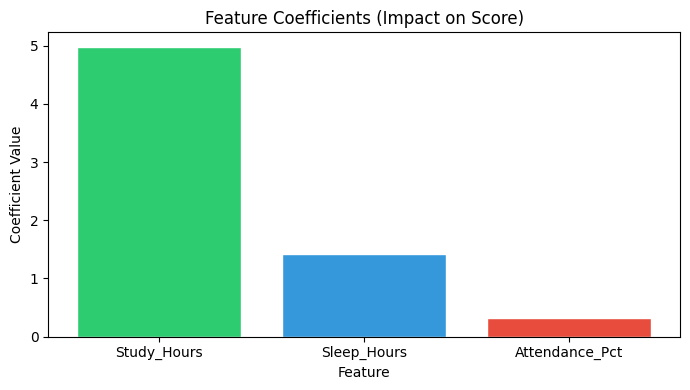

In [ ]:
# Coefficient importance bar chart
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(coef_df['Feature'], coef_df['Coefficient'],
        color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white')
plt.title('Feature Coefficients (Impact on Score)')
plt.ylabel('Coefficient Value')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

**Feature Coefficients (Impact on Score)**

Each coefficient tells you how much the score changes for every 1 unit increase in that feature.

- **Study_Hours (5.0)** — every additional hour of study adds **5 points** to the predicted score. Dominant driver by far.
- **Sleep_Hours (1.45)** — every extra hour of sleep adds ~**1.45 points**. Small but present contribution.
- **Attendance_Pct (0.3)** — every 1% increase in attendance adds only **0.3 points**. Minimal direct impact.

## 7. Predict a New Student's Score

In [ ]:
# Change these values to predict for any student
new_student = pd.DataFrame([{
    'Study_Hours':    10,
    'Attendance_Pct': 90.0,
    'Sleep_Hours':    7.0
}])

predicted_score = model.predict(new_student)[0]

print('Student Details:')
print(f'  Study Hours    : {new_student["Study_Hours"].values[0]}')
print(f'  Attendance %   : {new_student["Attendance_Pct"].values[0]}')
print(f'  Sleep Hours    : {new_student["Sleep_Hours"].values[0]}')
print(f'\nPredicted Score  : {predicted_score:.1f} / 100')

Student Details:
  Study Hours    : 10
  Attendance %   : 90.0
  Sleep Hours    : 7.0

Predicted Score  : 87.5 / 100
